In [1]:
# Imports and setup
import sys
from pathlib import Path

# Ensure project root is on sys.path so we can import src.test_strategy
proj_root = Path('..').resolve()
if str(proj_root) not in sys.path:
    sys.path.insert(0, str(proj_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.test_strategy import test_strategy

plt.rcParams['figure.figsize'] = (12, 6)


In [2]:
df = pd.read_csv('../tests/Sparebank 1 SR Bank ASA Stock Price History.csv', parse_dates=['Date'], index_col='Date')[::-1]
# df = pd.read_csv('../tests/DNB Stock Price History.csv', parse_dates=['Date'], index_col='Date')[::-1]
df_rf = pd.read_csv('../data/processed/10-Year-Government-Bond-Yield-Norway.csv', parse_dates=['Date'], index_col='Date')[::-1]

In [23]:
def RSI_scorer(df, period=14, ma_short=100, ma_long=200):
    """
    Calculate RSI and generate trading signals with multiple conditions.
    
    Buy Signal: RSI < 30
    Sell Signal: 
      - RSI > 70 AND Price < MA_long (trend weakness)
      - OR MA_short < MA_long (death cross)
    """
    delta = df['Price'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    df['RSI'] = rsi
    
    # Calculate moving averages
    df['MA50'] = df['Price'].rolling(window=50).mean()
    df['MA100'] = df['Price'].rolling(window=ma_short).mean()
    df['MA200'] = df['Price'].rolling(window=ma_long).mean()
    
    # Generate signals with multiple conditions
    df['Signal'] = 0
    for i in range(ma_long, len(df)):
        # Buy: RSI < 30 OR (MA14 > MA100)
        if (df['RSI'].iloc[i] < 30 and df['MA100'].iloc[i] > df['MA200'].iloc[i]) or df['MA50'].iloc[i] > df['MA100'].iloc[i]:
            df['Signal'].iloc[i] = 1
        # Sell: (RSI > 70 AND Price < MA200) OR (MA100 < MA200)
        if (df['RSI'].iloc[i] > 70 ) and df['Price'].iloc[i] < df['MA200'].iloc[i] or df['MA100'].iloc[i] < df['MA200'].iloc[i]:
            df['Signal'].iloc[i] = -1
    
    return df[max(ma_long, period):]  # Return DataFrame starting from the point where we have all indicators

C:\Users\naths\AppData\Local\Temp\ipykernel_16376\3429323229.py:27: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['Signal'].iloc[i] = 1
C:\Users\naths\AppData\Local\Temp\ipykernel_16376\3429323229.py:27: SettingWithCopyWarning: 
A value i

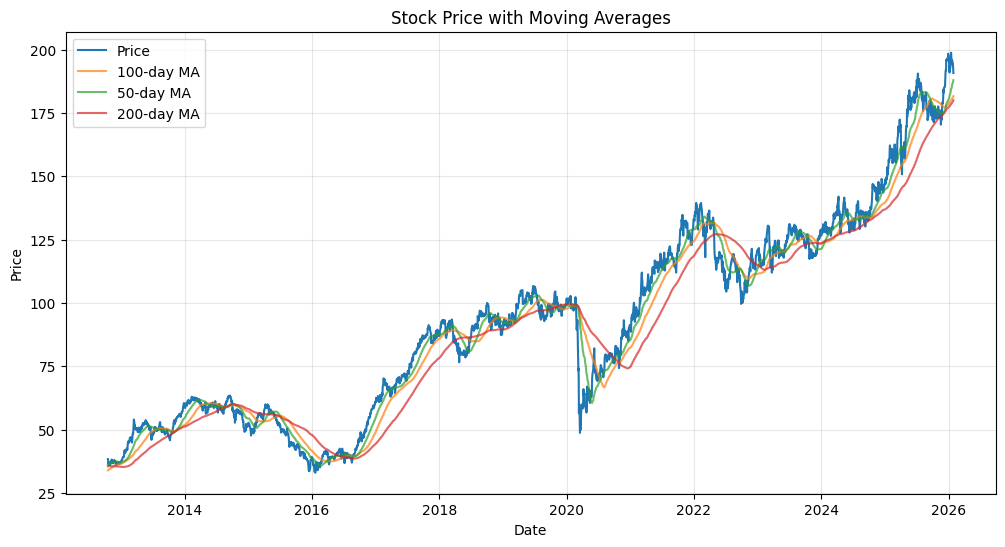

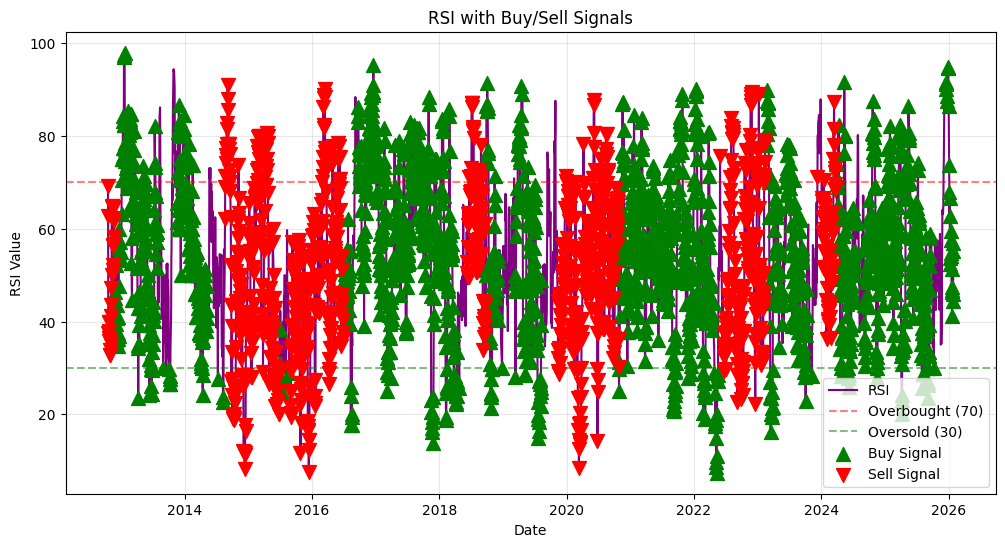

Buy signals (RSI < 30): 1788
Sell signals: 995


In [24]:
df_new = RSI_scorer(df, period=14, ma_short=100, ma_long=200)

# Plot Price with Moving Averages
plt.figure(figsize=(12, 6))
plt.plot(df_new.index, df_new['Price'], label='Price', linewidth=1.5)
plt.plot(df_new.index, df_new['MA100'], label='100-day MA', alpha=0.7, linewidth=1.5)
plt.plot(df_new.index, df_new['MA50'], label='50-day MA', alpha=0.7, linewidth=1.5)
plt.plot(df_new.index, df_new['MA200'], label='200-day MA', alpha=0.7, linewidth=1.5)
plt.title('Stock Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Plot RSI with signals
plt.figure(figsize=(12, 6))
plt.plot(df_new.index, df_new['RSI'], label='RSI', color='purple')
plt.axhline(70, color='red', linestyle='--', label='Overbought (70)', alpha=0.5)
plt.axhline(30, color='green', linestyle='--', label='Oversold (30)', alpha=0.5)
plt.scatter(df_new[df_new['Signal'] == 1].index, df_new[df_new['Signal'] == 1]['RSI'], 
            color='green', marker='^', s=100, label='Buy Signal', zorder=5)
plt.scatter(df_new[df_new['Signal'] == -1].index, df_new[df_new['Signal'] == -1]['RSI'], 
            color='red', marker='v', s=100, label='Sell Signal', zorder=5)
plt.title('RSI with Buy/Sell Signals') 
plt.xlabel('Date')
plt.ylabel('RSI Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Buy signals (RSI < 30): {(df_new['Signal'] == 1).sum()}")
print(f"Sell signals: {(df_new['Signal'] == -1).sum()}")

In [25]:
# --- Log returns ---
df_new['Daily Return'] = np.log(df_new['Price'] / df_new['Price'].shift(1))

# --- Risk free daily log return ---
rf_daily = (df_rf['Price'] / 100) / 252
rf_log = np.log(1 + rf_daily)

# --- Position (vectorized, no loop needed) ---
df_new['Position'] = 0
position = 0

for i in range(1, len(df_new)):
    signal = df_new['Signal'].iloc[i-1]

    if signal == 1:
        position = 1
    elif signal == -1:
        position = 0

    df_new.loc[df_new.index[i], 'Position'] = position

# --- Strategy log return ---
df_new['Strategy Return'] = (
    df_new['Position'] * df_new['Daily Return'] +
    (1 - df_new['Position']) * rf_log
)

df_new['Strategy Return'] = df_new['Strategy Return'].fillna(0)

# --- Proper cumulative growth (log returns → exp of sum) ---
df_new['Market Index'] = np.exp(df_new['Daily Return'].cumsum())
df_new['Strategy Index'] = np.exp(df_new['Strategy Return'].cumsum())

# Normalize to 100
df_new[['Market Index', 'Strategy Index']] = \
df_new[['Market Index', 'Strategy Index']] / \
df_new[['Market Index', 'Strategy Index']].iloc[0] * 100

# --- Final performance ---
total_market_return = df_new['Market Index'].iloc[-1] / 100 - 1
total_strategy_return = df_new['Strategy Index'].iloc[-1] / 100 - 1

print(f"Total Market Return: {total_market_return:.2%}")
print(f"Total Strategy Return: {total_strategy_return:.2%}")

# --- Trades ---
num_trades = (df_new['Position'].diff().abs() == 1).sum() // 2
print(f"Number of trades executed: {num_trades}")

# --- Signal counts ---
print(f"Buy signals: {(df_new['Signal'] == 1).sum()}")
print(f"Sell signals: {(df_new['Signal'] == -1).sum()}")

# --- Time in market ---
time_in_market = df_new['Position'].mean()
print(f"Percentage of time in market: {time_in_market:.2%}")


C:\Users\naths\AppData\Local\Temp\ipykernel_16376\600361420.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['Daily Return'] = np.log(df_new['Price'] / df_new['Price'].shift(1))
C:\Users\naths\AppData\Local\Temp\ipykernel_16376\600361420.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['Position'] = 0


Total Market Return: nan%
Total Strategy Return: 576.92%
Number of trades executed: 6
Buy signals: 1788
Sell signals: 995
Percentage of time in market: 69.31%


C:\Users\naths\AppData\Local\Temp\ipykernel_16376\600361420.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['Strategy Return'] = (
C:\Users\naths\AppData\Local\Temp\ipykernel_16376\600361420.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['Strategy Return'] = df_new['Strategy Return'].fillna(0)
C:\Users\naths\AppData\Local\Temp\ipykernel_16376\600361420.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_in

                            OLS Regression Results                            
Dep. Variable:           excess_strat   R-squared:                       0.132
Model:                            OLS   Adj. R-squared:                  0.132
Method:                 Least Squares   F-statistic:                     503.2
Date:                Tue, 03 Mar 2026   Prob (F-statistic):          7.44e-104
Time:                        11:30:17   Log-Likelihood:                 10350.
No. Observations:                3309   AIC:                        -2.070e+04
Df Residuals:                    3307   BIC:                        -2.068e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0003      0.000      1.641      0.1

{'model': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x1eae2a21c90>,
 'series': {'strategy_log': Date
  2012-10-17    0.000000
  2012-10-18    0.000084
  2012-10-19    0.000084
  2012-10-22    0.000085
  2012-10-23    0.000084
                  ...   
  2026-01-23    0.000000
  2026-01-26    0.000000
  2026-01-27    0.000000
  2026-01-28    0.000000
  2026-01-29    0.000000
  Name: strategy, Length: 3330, dtype: float64,
  'strategy_simple': Date
  2012-10-17    0.000000
  2012-10-18    0.000084
  2012-10-19    0.000084
  2012-10-22    0.000085
  2012-10-23    0.000084
                  ...   
  2026-01-23    0.000000
  2026-01-26    0.000000
  2026-01-27    0.000000
  2026-01-28    0.000000
  2026-01-29    0.000000
  Name: strategy_simple, Length: 3330, dtype: float64,
  'market_log': Date
  2012-10-17   -0.001802
  2012-10-18   -0.002904
  2012-10-19   -0.005415
  2012-10-22   -0.005415
  2012-10-23   -0.029635
                  ...   
  2026-01-23         NaN
 

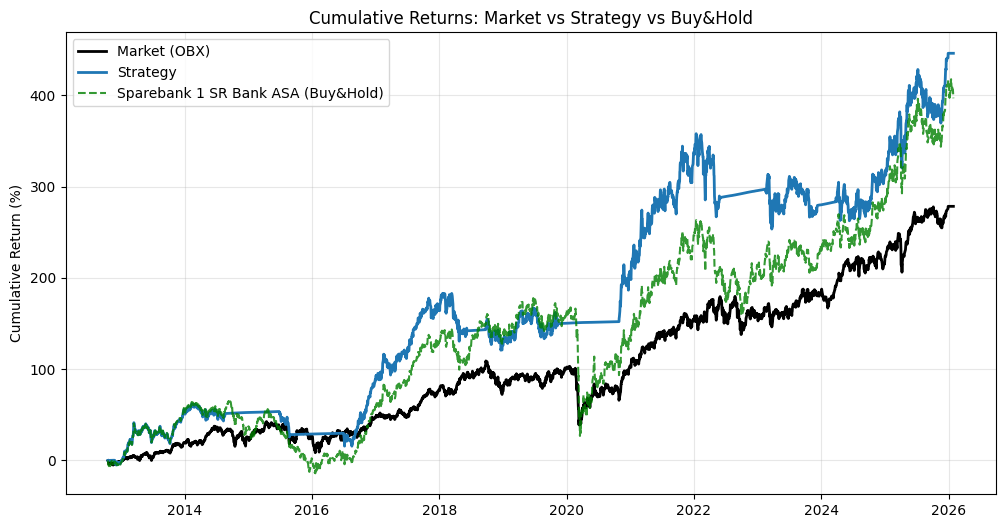

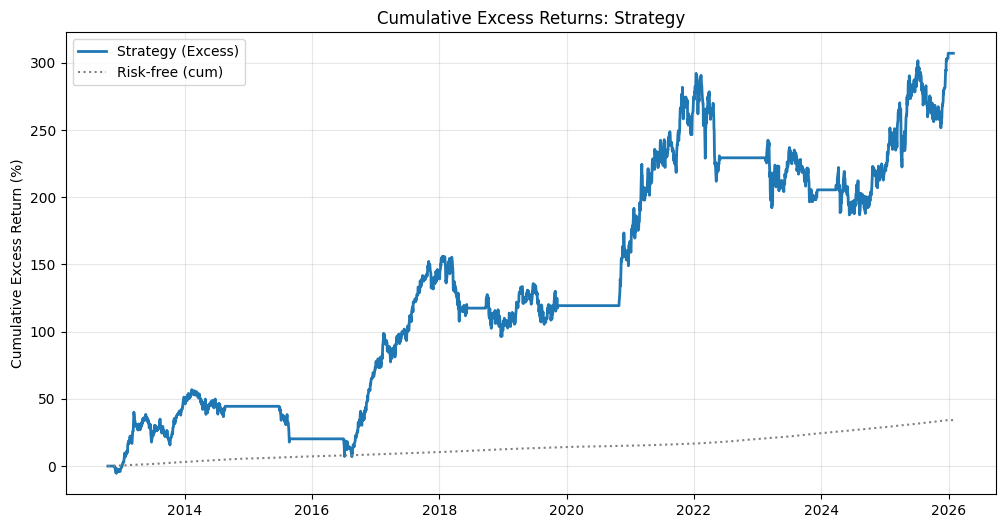

In [26]:
test_strategy(
    strategy_returns=df_new['Strategy Return'],
    underlying_prices=[df_new['Price']],
    underlying_names=['Sparebank 1 SR Bank ASA'],
    dates=df_new.index,
    data_dir=str(proj_root / 'data' / 'processed'),
    plot_index=True,
)

In [7]:
print(len(df_new) / 252)
np.exp(np.cumsum(np.repeat(0.0003, len(df_new))))[-1]

13.214285714285714


2.71556490531846